<a href="https://colab.research.google.com/github/aakankshalahane/SQL-Projects-/blob/main/Stock_Market_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stock Market Summary


,Trading_Days,Lowest_Price,Highest_Price,Average_Closing_Price,Total_Trading_Volume
0,15,183.0,214.0,200.0,25970000


Daily Market Performance


,Date,Open,High,Low,Close,Volume,Daily_Change,Daily_Return_Percent
0,2025-01-02 00:00:00,185,190,183,188,1200000,3.0,0.0
1,2025-01-03 00:00:00,188,192,185,190,1350000,2.0,0.0
2,2025-01-06 00:00:00,187,193,185,192,1100000,5.0,0.0
3,2025-01-07 00:00:00,191,195,188,194,1500000,3.0,0.0
4,2025-01-08 00:00:00,194,198,191,196,1420000,2.0,0.0
5,2025-01-09 00:00:00,193,197,190,195,1600000,2.0,0.0
6,2025-01-10 00:00:00,196,200,193,199,1750000,3.0,0.0
7,2025-01-13 00:00:00,198,203,196,201,1680000,3.0,0.0
8,2025-01-14 00:00:00,201,204,198,202,1900000,1.0,0.0
9,2025-01-15 00:00:00,199,203,197,201,1550000,2.0,0.0


Best Performing Days


,Date,Close,Return_Percent
0,2025-01-02 00:00:00,188,0.0
1,2025-01-03 00:00:00,190,0.0
2,2025-01-06 00:00:00,192,0.0
3,2025-01-07 00:00:00,194,0.0
4,2025-01-08 00:00:00,196,0.0


Highest Trading Volume Days


,Date,Volume,Close
0,2025-01-22 00:00:00,2450000,211
1,2025-01-21 00:00:00,2300000,209
2,2025-01-20 00:00:00,2250000,210
3,2025-01-17 00:00:00,2100000,207
4,2025-01-14 00:00:00,1900000,202


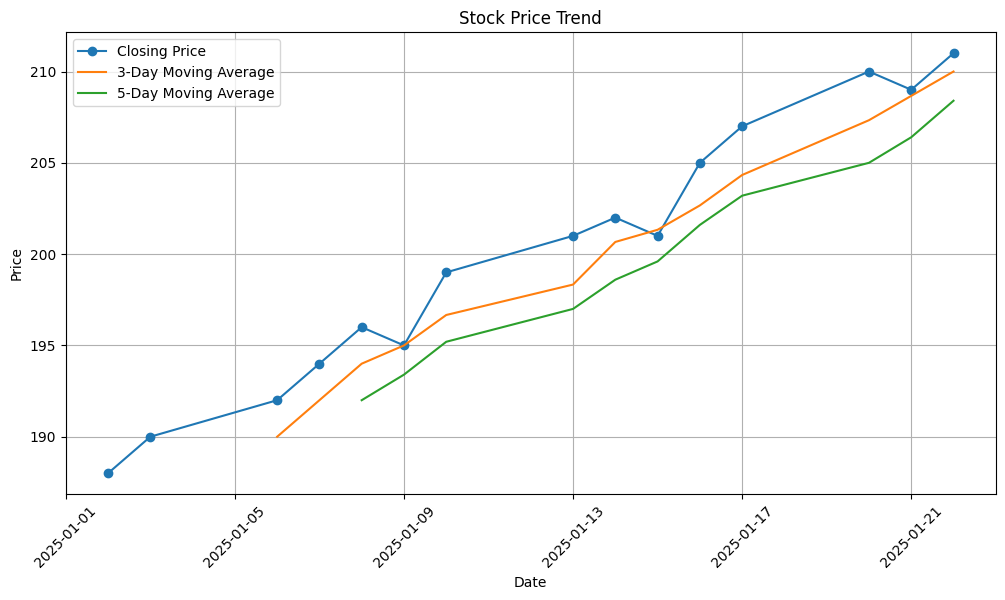

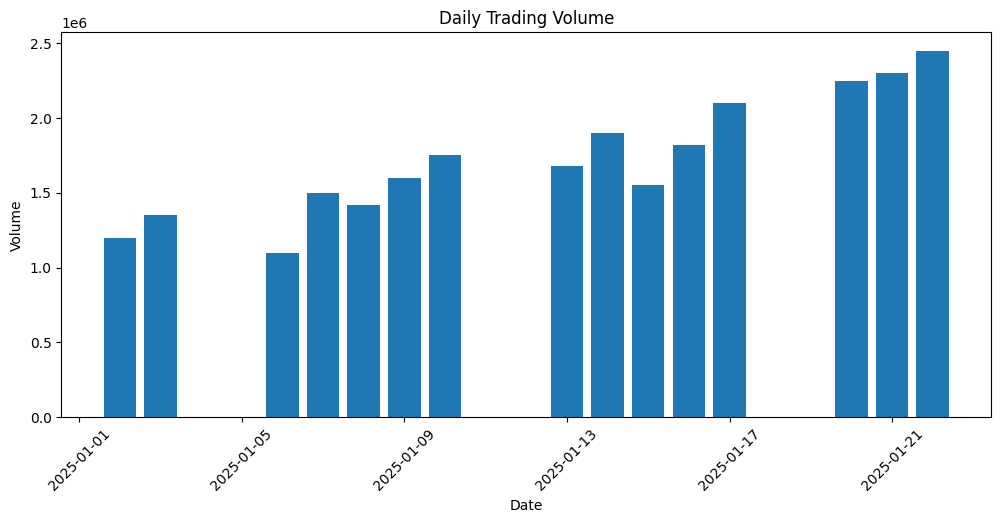

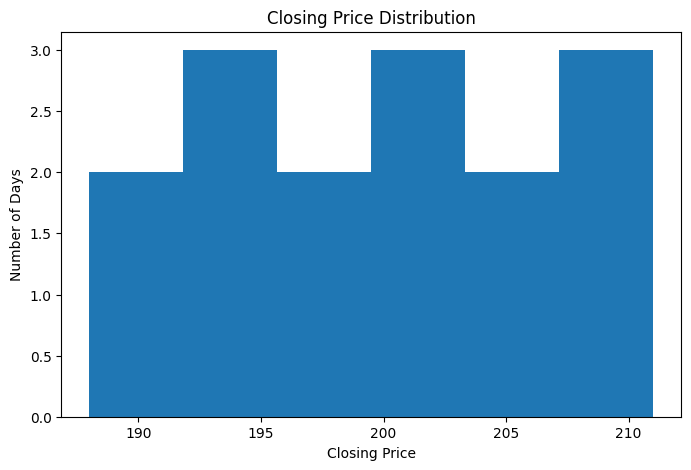

Stock Market Analytics completed successfully.


In [ ]:
# Install required library
!pip -q install pandas matplotlib

# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
stock_data = {
    "Date": [
        "2025-01-02","2025-01-03","2025-01-06","2025-01-07","2025-01-08",
        "2025-01-09","2025-01-10","2025-01-13","2025-01-14","2025-01-15",
        "2025-01-16","2025-01-17","2025-01-20","2025-01-21","2025-01-22"
    ],
    "Company": [
        "TechCorp","TechCorp","TechCorp","TechCorp","TechCorp",
        "TechCorp","TechCorp","TechCorp","TechCorp","TechCorp",
        "TechCorp","TechCorp","TechCorp","TechCorp","TechCorp"
    ],
    "Open": [
        185,188,187,191,194,193,196,198,201,199,203,205,207,210,208
    ],
    "High": [
        190,192,193,195,198,197,200,203,204,203,207,209,211,214,212
    ],
    "Low": [
        183,185,185,188,191,190,193,196,198,197,200,202,204,207,205
    ],
    "Close": [
        188,190,192,194,196,195,199,201,202,201,205,207,210,209,211
    ],
    "Volume": [
        1200000,1350000,1100000,1500000,1420000,
        1600000,1750000,1680000,1900000,1550000,
        1820000,2100000,2250000,2300000,2450000
    ]
}

df = pd.DataFrame(stock_data)

# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Create SQLite database
connection = sqlite3.connect(":memory:")

df.to_sql("stock_market", connection, index=False, if_exists="replace")

# Basic stock summary
summary = pd.read_sql_query("""
SELECT
    COUNT(*) AS Trading_Days,
    ROUND(MIN(Low), 2) AS Lowest_Price,
    ROUND(MAX(High), 2) AS Highest_Price,
    ROUND(AVG(Close), 2) AS Average_Closing_Price,
    SUM(Volume) AS Total_Trading_Volume
FROM stock_market
""", connection)

print("Stock Market Summary")
display(summary)

# Daily price analysis
daily_analysis = pd.read_sql_query("""
SELECT
    Date,
    Open,
    High,
    Low,
    Close,
    Volume,
    ROUND(Close - Open, 2) AS Daily_Change,
    ROUND(((Close - Open) / Open) * 100, 2) AS Daily_Return_Percent
FROM stock_market
ORDER BY Date
""", connection)

print("Daily Market Performance")
display(daily_analysis)

# Best performing days
best_days = pd.read_sql_query("""
SELECT
    Date,
    Close,
    ROUND(((Close - Open) / Open) * 100, 2) AS Return_Percent
FROM stock_market
ORDER BY Return_Percent DESC
LIMIT 5
""", connection)

print("Best Performing Days")
display(best_days)

# Highest trading volume
high_volume = pd.read_sql_query("""
SELECT
    Date,
    Volume,
    Close
FROM stock_market
ORDER BY Volume DESC
LIMIT 5
""", connection)

print("Highest Trading Volume Days")
display(high_volume)

# Calculate moving averages
df["MA_3"] = df["Close"].rolling(3).mean()
df["MA_5"] = df["Close"].rolling(5).mean()

# Price trend
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], marker="o", label="Closing Price")
plt.plot(df["Date"], df["MA_3"], label="3-Day Moving Average")
plt.plot(df["Date"], df["MA_5"], label="5-Day Moving Average")
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# Trading volume
plt.figure(figsize=(12, 5))
plt.bar(df["Date"], df["Volume"])
plt.title("Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

# Closing price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Close"], bins=6)
plt.title("Closing Price Distribution")
plt.xlabel("Closing Price")
plt.ylabel("Number of Days")
plt.show()

connection.close()

print("Stock Market Analytics completed successfully.")